## Лабораторна робота №3  
### Візуалізація даних

##### У цій роботі використовується датасет Adult з UCI Machine Learning Repository.  
##### Метою є очищення даних, аналіз та візуалізація залежностей між ознаками.

##### Датасет містить демографічні характеристики людей та інформацію про їхній дохід.

##### Методи візуалізації даних, використані в роботі, можуть застосовуватись у сфері кібербезпеки,
##### зокрема для аналізу мережевого трафіку, виявлення аномалій та класифікації атак (IDS/IPS).

### 1. Завантаження датасету

In [16]:
#Імпорт необхідних бібліотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", palette="pastel")

In [17]:
# Налаштування стилю
sns.set_theme(style="ticks", palette="pastel")

# Завантаження датасету
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

# na_values=" ?" прибирає знаки питання
df = pd.read_csv(url, names=columns, na_values=" ?", skipinitialspace=True)

print("Дані завантажено! Ось перші 5 рядків:")
df.head()

Дані завантажено! Ось перші 5 рядків:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### 2. Первинний аналіз даних
#### 2.1 Перегляд структури даних

In [18]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [19]:
# Використовуємо `df.info()` для перевірки типів даних та наявності явних пропусків.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


#### 2.3 Статистичний аналіз

In [20]:
#Використовуємо `df.describe()` для оцінки розподілу числових ознак.
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


### 3. Data Cleaning

In [21]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [22]:
for col in ['workclass', 'occupation', 'native_country']:
    df[col] = df[col].fillna(df[col].mode()[0])

df.drop_duplicates(inplace=True)

### 4. Перетворення змінної доходу

In [39]:
df['income_binary'] = df['income'].str.strip().map({'<=50K': 0, '>50K': 1})

In [42]:
print(df.isnull().sum()) 
print(df[['income', 'income_binary']].head())  

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
income_binary     0
dtype: int64
  income  income_binary
0  <=50K              0
1  <=50K              0
2  <=50K              0
3  <=50K              0
4  <=50K              0


## ВІЗУАЛІЗАЦІЯ

### 5. Scatter Plot

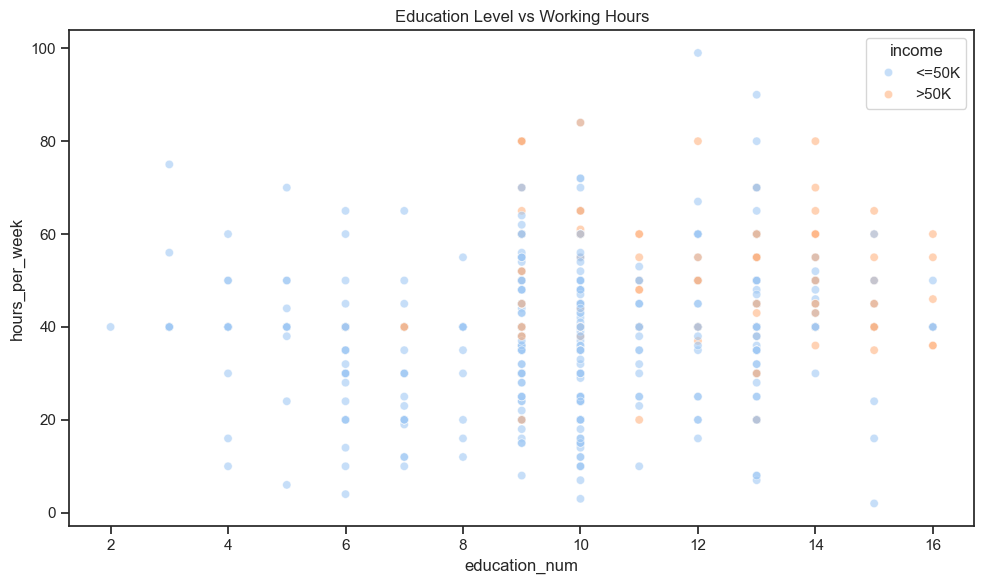

In [40]:
# Залежність між рівнем освіти та кількістю робочих годин
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(1000),
    x="education_num",
    y="hours_per_week",
    hue="income",
    alpha=0.6
)

plt.title("Education Level vs Working Hours")
plt.tight_layout()
plt.show()

#### Висновок: Люди з вищим рівнем освіти частіше мають стабільні робочі години та більший дохід.

### 6. Histogram (5 bins)

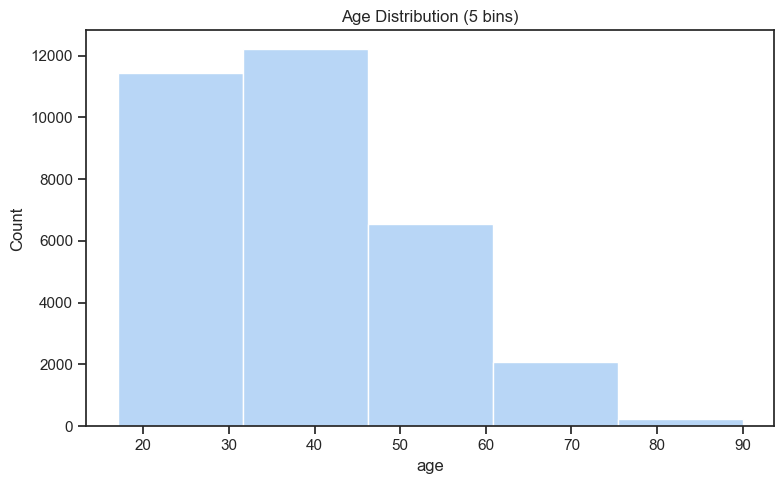

In [41]:
# Розподіл віку (5 діапазонів)
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=5)

plt.title("Age Distribution (5 bins)")
plt.tight_layout()
plt.show()

#### Висновок: Основна частина населення знаходиться у віковому діапазоні 30–50 років.

### 7. Multi-dimensional Scatter

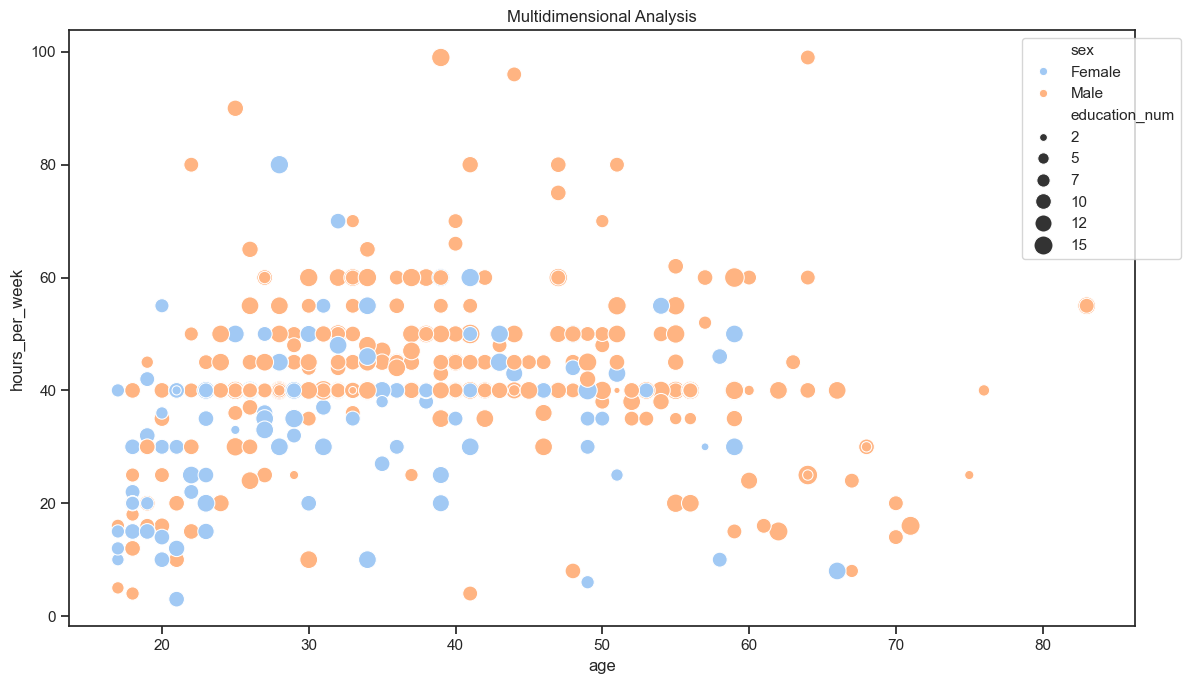

In [34]:
# Багатовимірна візуалізація
#Графік демонструє залежність між віком та кількістю робочих годин,
#використовуючи додаткові виміри:
#- колір (стать)
#- розмір (рівень освіти)
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df.sample(500),
    x="age",
    y="hours_per_week",
    hue="sex",
    size="education_num",
    sizes=(20, 200)
)

plt.title("Multidimensional Analysis")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

#### Висновок: Незалежно від статі, більшість людей працює приблизно однакову кількість годин.

### 8. Boxplot

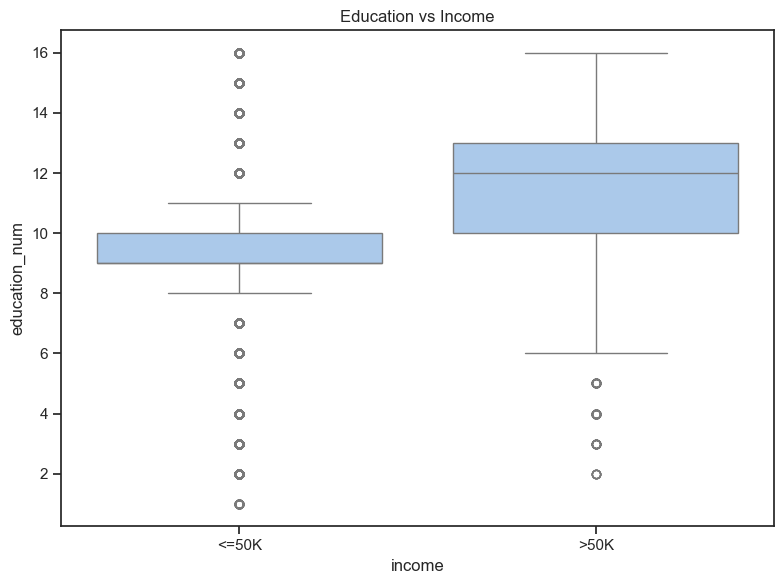

In [35]:
# Рівень освіти та дохід
plt.figure(figsize=(8,6))

sns.boxplot(x="income", y="education_num", data=df)

plt.title("Education vs Income")
plt.tight_layout()
plt.show()

#### Висновок: Вищий рівень освіти значно підвищує ймовірність отримання високого доходу.

### 9. Heatmap (clean version)

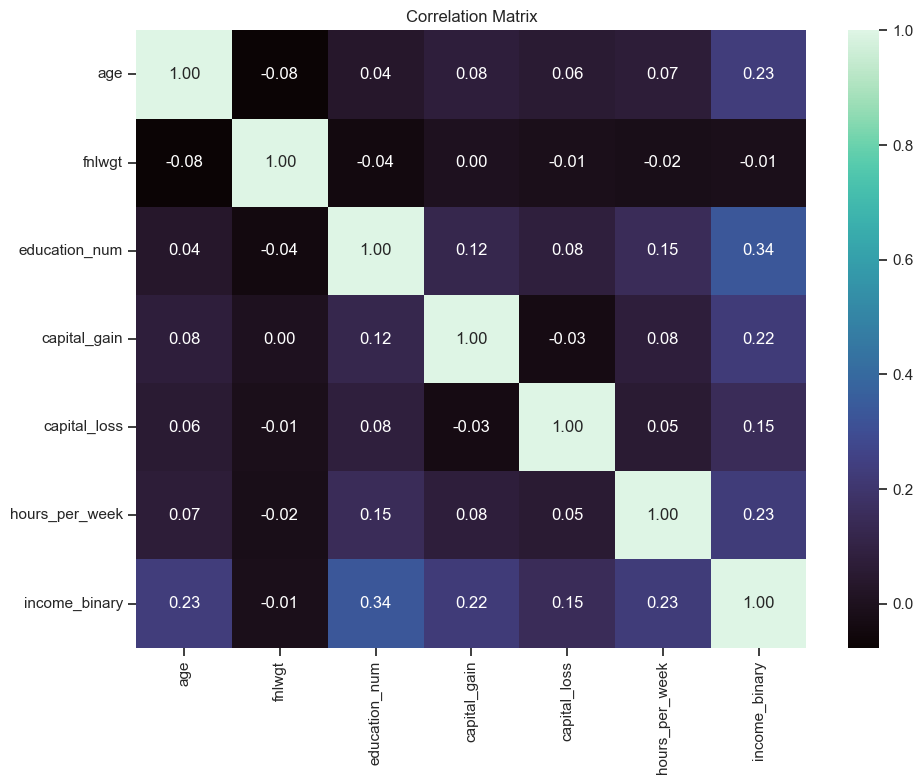

In [36]:
# Кореляційна матриця
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=[np.number]).corr(),
    annot=True,
    cmap="mako",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

#### Висновок: Найбільш помітна кореляція спостерігається між рівнем освіти та доходом.

### 10. Violin Plot

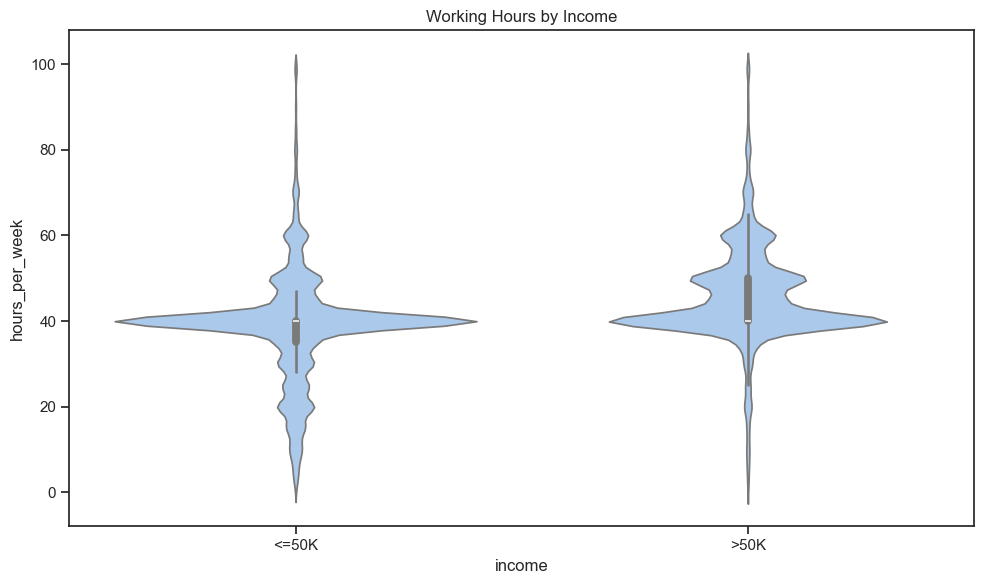

In [37]:
# Розподіл робочих годин залежно від доходу
plt.figure(figsize=(10,6))

sns.violinplot(x="income", y="hours_per_week", data=df)

plt.title("Working Hours by Income")
plt.tight_layout()
plt.show()

#### Висновок: Люди з високим доходом мають ширший та більш варіативний розподіл робочих годин.

### 11. Pairplot

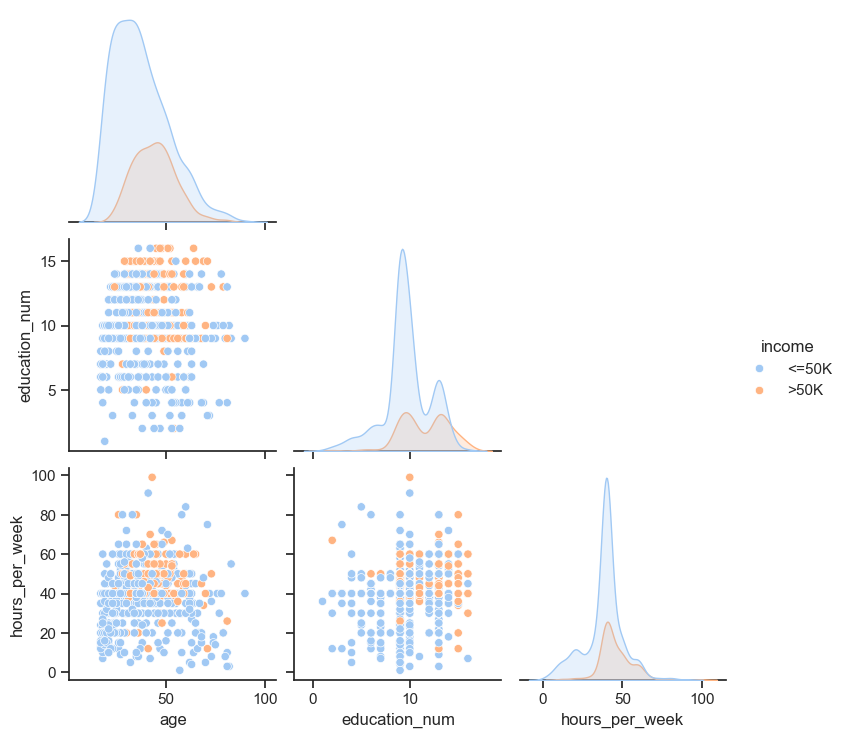

In [38]:
# Комплексний аналіз змінних
sns.pairplot(
    df.sample(1000)[['age','education_num','hours_per_week','income']],
    hue='income',
    corner=True
)

plt.show()

#### Висновок: Освіта є одним із ключових факторів, що впливають на рівень доходу.

### 12. Загальні висновки

##### 1. Аналіз гістограми віку показав, що найбільша частка респондентів знаходиться у діапазоні 30–50 років, що свідчить про переважання економічно активного населення.

##### 2. На основі boxplot та countplot встановлено, що зі зростанням рівня освіти збільшується ймовірність отримання вищого доходу, що підтверджує наявність прямої залежності між освітою та фінансовим станом.

##### 3. Гістограма розподілу робочих годин показала, що більшість людей працює близько 40 годин на тиждень, що відповідає стандартному робочому графіку.

##### 4. Scatter plot та boxplot не виявили суттєвих відмінностей у кількості відпрацьованих годин між чоловіками та жінками, що свідчить про відносну рівність у цьому показнику.

##### 5. Heatmap кореляцій підтвердила, що освіта є одним із ключових факторів, які впливають на рівень доходу, поряд із віком та кількістю робочих годин.